In [2]:
import numpy as np
import pandas as pd
from google.colab import drive

# 1. 드라이브 마운트
drive.mount('/content/drive')

# 2. 파일 읽기
file_path = '/content/drive/MyDrive/healthdata.CSV'

try:
    cs_df = pd.read_csv(file_path, encoding='cp949')
    print("파일 읽기 성공!")

except FileNotFoundError:
    print(f"에러: {file_path} 경로에 파일이 없습니다. 파일명을 다시 확인해주세요!")

Mounted at /content/drive
파일 읽기 성공!


# **데이터 전처리 & 라벨링**

In [3]:
# 데이터 라벨링
cs_df['target'] = np.where((cs_df['수축기혈압'] >= 140) & (cs_df['이완기혈압'] >= 90), 1, 0)

# BMI 지수 (-> 비만 판단)
cs_df['BMI'] = cs_df['체중(5kg단위)'] / ((cs_df['신장(5cm단위)'] / 100) ** 2)

# 불필요한 column drop
cols_to_drop = [
    '기준년도', '가입자일련번호', '시도코드',
    '시력(좌)', '시력(우)', '청력(좌)', '청력(우)',
    '혈청지오티(AST)', '혈청지피티(ALT)', '구강검진수검여부',
    '총콜레스테롤', '트리글리세라이드', 'HDL콜레스테롤', 'LDL콜레스테롤',
    '치아우식증유무', '결손치 유무', '치아마모증유무',
    '제3대구치(사랑니) 이상', '치석'
]
cs_df = cs_df.drop(columns=cols_to_drop)

# BMI 지수에 다른 비만여부
bins = [0, 18.5, 23, 25, 30, 100]
labels = ['저체중', '정상', '과체중', '비만', '고도비만']

cs_df['비만여부'] = pd.cut(cs_df['BMI'], bins=bins, labels=labels, right=False)

print(cs_df.columns)


Index(['성별코드', '연령대코드(5세단위)', '신장(5cm단위)', '체중(5kg단위)', '허리둘레', '수축기혈압',
       '이완기혈압', '식전혈당(공복혈당)', '혈색소', '요단백', '혈청크레아티닌', '감마지티피', '흡연상태', '음주여부',
       'target', 'BMI', '비만여부'],
      dtype='object')


# **실험결과 시각화**

고혈압 여부에 따른 BMI와 허리둘레 분포

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 16.8 MB/s eta 0:00:00


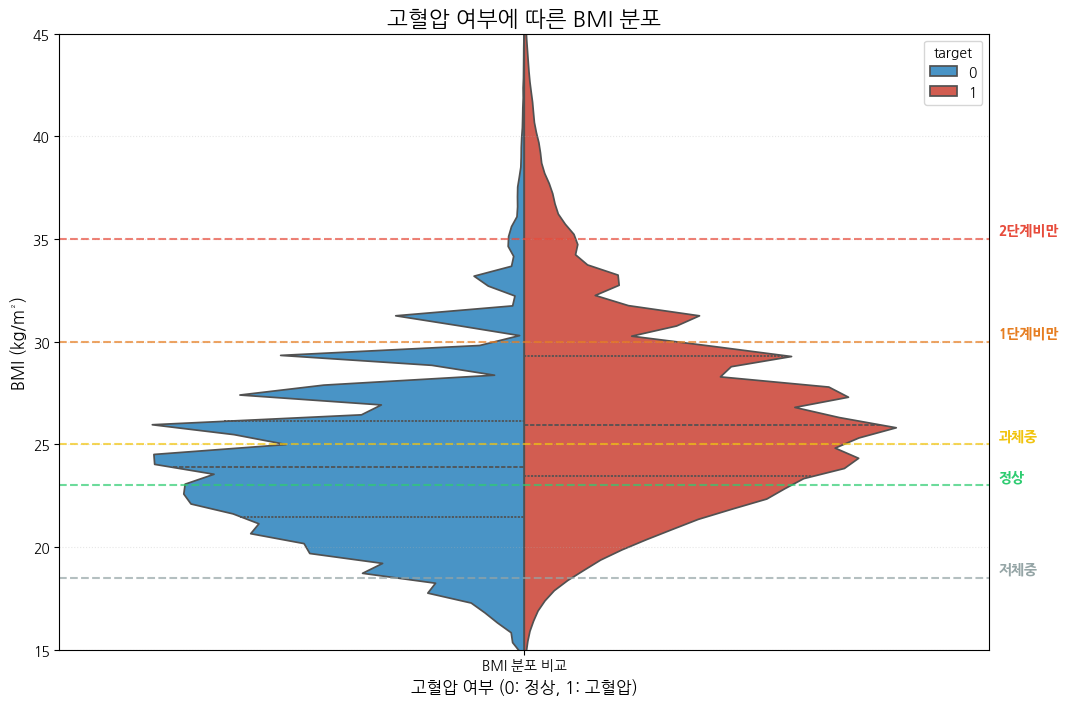

In [5]:
!pip install koreanize-matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

plt.figure(figsize=(12, 8))

# 1. 바이올린 플롯 그리기
cs_df['분포'] = 'BMI 분포 비교'
sns.violinplot(data=cs_df, x='분포', y='BMI', hue='target',
               split=True, inner='quartile', palette={0: '#3498db', 1: '#e74c3c'})

# 2. 대한비만학회 기준 가로선 추가
# 저체중(18.5), 정상(23), 과체중(25), 1단계비만(30), 2단계비만(35)
thresholds = [18.5, 23, 25, 30, 35]
labels = ['저체중', '정상', '과체중', '1단계비만', '2단계비만']
colors = ['#95a5a6', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

for line, label, color in zip(thresholds, labels, colors):
    plt.axhline(y=line, color=color, linestyle='--', linewidth=1.5, alpha=0.7)
    plt.text(0.51, line + 0.1, label, color=color, fontweight='bold', va='bottom', fontsize=10)

# 3. 그래프 꾸미기
plt.title('고혈압 여부에 따른 BMI 분포', fontsize=16)
plt.xlabel('고혈압 여부 (0: 정상, 1: 고혈압)', fontsize=12)
plt.ylabel('BMI (kg/m²)', fontsize=12)
plt.ylim(15, 45)
plt.grid(axis='y', linestyle=':', alpha=0.3)

plt.show()

당뇨-고혈압의 상관관계

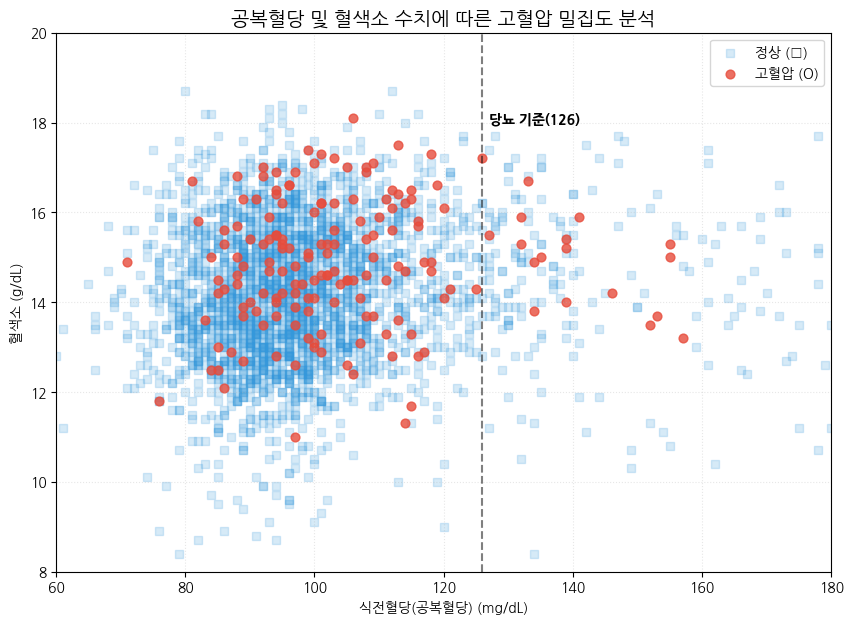

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 1. 시각화를 위한 샘플링
df_sample = cs_df.sample(3000, random_state=42)

# 2. 가시성 확보를 위해 두 집단을 분리
df_normal = df_sample[df_sample['target'] == 0]     # 정상군
df_hypert = df_sample[df_sample['target'] == 1]     # 고혈압군

plt.figure(figsize=(10, 7))

# 3. 시각화
plt.scatter(df_normal['식전혈당(공복혈당)'], df_normal['혈색소'],
            marker='s', color='#3498db', alpha=0.2, label='정상 (□)', s=30)

plt.scatter(df_hypert['식전혈당(공복혈당)'], df_hypert['혈색소'],
            marker='o', color='#e74c3c', alpha=0.8, label='고혈압 (O)', s=40)

# 4. 분석 가이드라인 추가
plt.axvline(x=126, color='black', linestyle='--', alpha=0.5)
plt.text(127, 18, '당뇨 기준(126)', color='black', fontsize=10, fontweight='bold')

# 5. 그래프 세부 설정
plt.xlim(60, 180)
plt.ylim(8, 20)
plt.title('공복혈당 및 혈색소 수치에 따른 고혈압 밀집도 분석', fontsize=14)
plt.xlabel('식전혈당(공복혈당) (mg/dL)')
plt.ylabel('혈색소 (g/dL)')
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle=':', alpha=0.3)

plt.show()

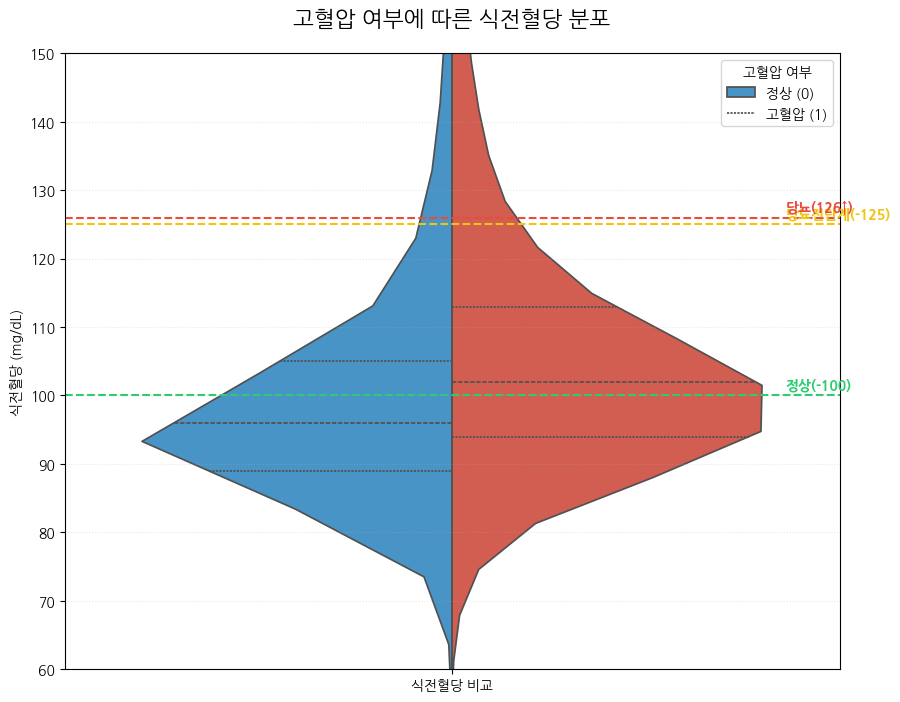

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

cs_df['target'] = cs_df['target'].astype(str)
plt.figure(figsize=(10, 8))

# 1. Split Violin Plot 그리기
cs_df['분포_혈당'] = '식전혈당 비교'
sns.violinplot(data=cs_df, x='분포_혈당', y='식전혈당(공복혈당)', hue='target',
               split=True, inner='quartile', palette={'0': '#3498db', '1': '#e74c3c'})

# 2. 가로선 추가 (정상: 100 미만, 당뇨: 125 이상)
thresholds = [100, 125, 126]
labels = ['정상(-100)', '당뇨전단계(-125)', '당뇨(126↑)']
colors = ['#2ecc71', '#f1c40f', '#e74c3c']

for line, label, color in zip(thresholds, labels, colors):
    plt.axhline(y=line, color=color, linestyle='--', linewidth=1.5)
    plt.text(0.43, line + 1, label, color=color, fontweight='bold')

# 3. 그래프 세부 설정
plt.ylim(60, 150) # 요청하신 범위 적용
plt.title('고혈압 여부에 따른 식전혈당 분포', fontsize=16, pad=20)
plt.ylabel('식전혈당 (mg/dL)')
plt.xlabel('')
plt.legend(title='고혈압 여부', labels=['정상 (0)', '고혈압 (1)'])
plt.grid(axis='y', linestyle=':', alpha=0.3)

plt.show()

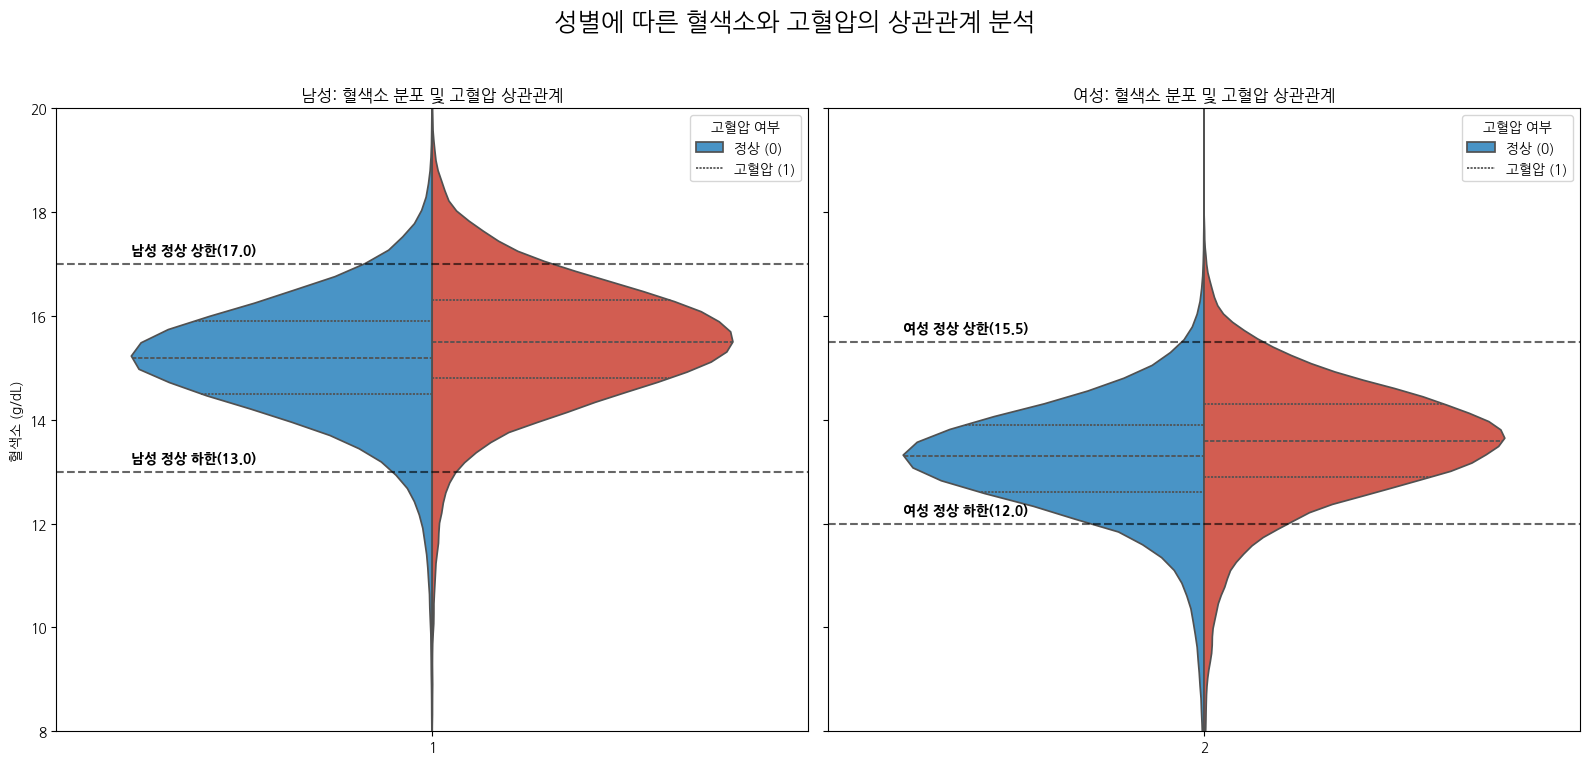

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 성별 데이터 분리 (1: 남성, 2: 여성)
male_df = cs_df[cs_df['성별코드'] == 1].copy()
female_df = cs_df[cs_df['성별코드'] == 2].copy()

male_df['target'] = male_df['target'].astype(str)
female_df['target'] = female_df['target'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# --- [좌: 남성 혈색소 분석] ---
sns.violinplot(data=male_df, x='성별코드', y='혈색소', hue='target', split=True,
               inner='quartile', palette={'0': '#3498db', '1': '#e74c3c'}, ax=axes[0])
# 남성 정상 범위 가로선
axes[0].axhline(y=13.0, color='black', linestyle='--', alpha=0.6)
axes[0].axhline(y=17.0, color='black', linestyle='--', alpha=0.6)
axes[0].text(-0.4, 13.2, '남성 정상 하한(13.0)', fontweight='bold')
axes[0].text(-0.4, 17.2, '남성 정상 상한(17.0)', fontweight='bold')
axes[0].set_title('남성: 혈색소 분포 및 고혈압 상관관계')

# --- [우: 여성 혈색소 분석] ---
sns.violinplot(data=female_df, x='성별코드', y='혈색소', hue='target', split=True,
               inner='quartile', palette={'0': '#3498db', '1': '#e74c3c'}, ax=axes[1])
# 여성 정상 범위 가로선
axes[1].axhline(y=12.0, color='black', linestyle='--', alpha=0.6)
axes[1].axhline(y=15.5, color='black', linestyle='--', alpha=0.6)
axes[1].text(-0.4, 12.2, '여성 정상 하한(12.0)', fontweight='bold')
axes[1].text(-0.4, 15.7, '여성 정상 상한(15.5)', fontweight='bold')
axes[1].set_title('여성: 혈색소 분포 및 고혈압 상관관계')

# 공통 설정
for ax in axes:
    ax.set_ylim(8, 20)
    ax.set_xlabel('')
    ax.set_ylabel('혈색소 (g/dL)')
    ax.legend(title='고혈압 여부', labels=['정상 (0)', '고혈압 (1)'])

plt.suptitle('성별에 따른 혈색소와 고혈압의 상관관계 분석', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

성별에 따른 감마지티피 수치와 고혈압의 상관관계

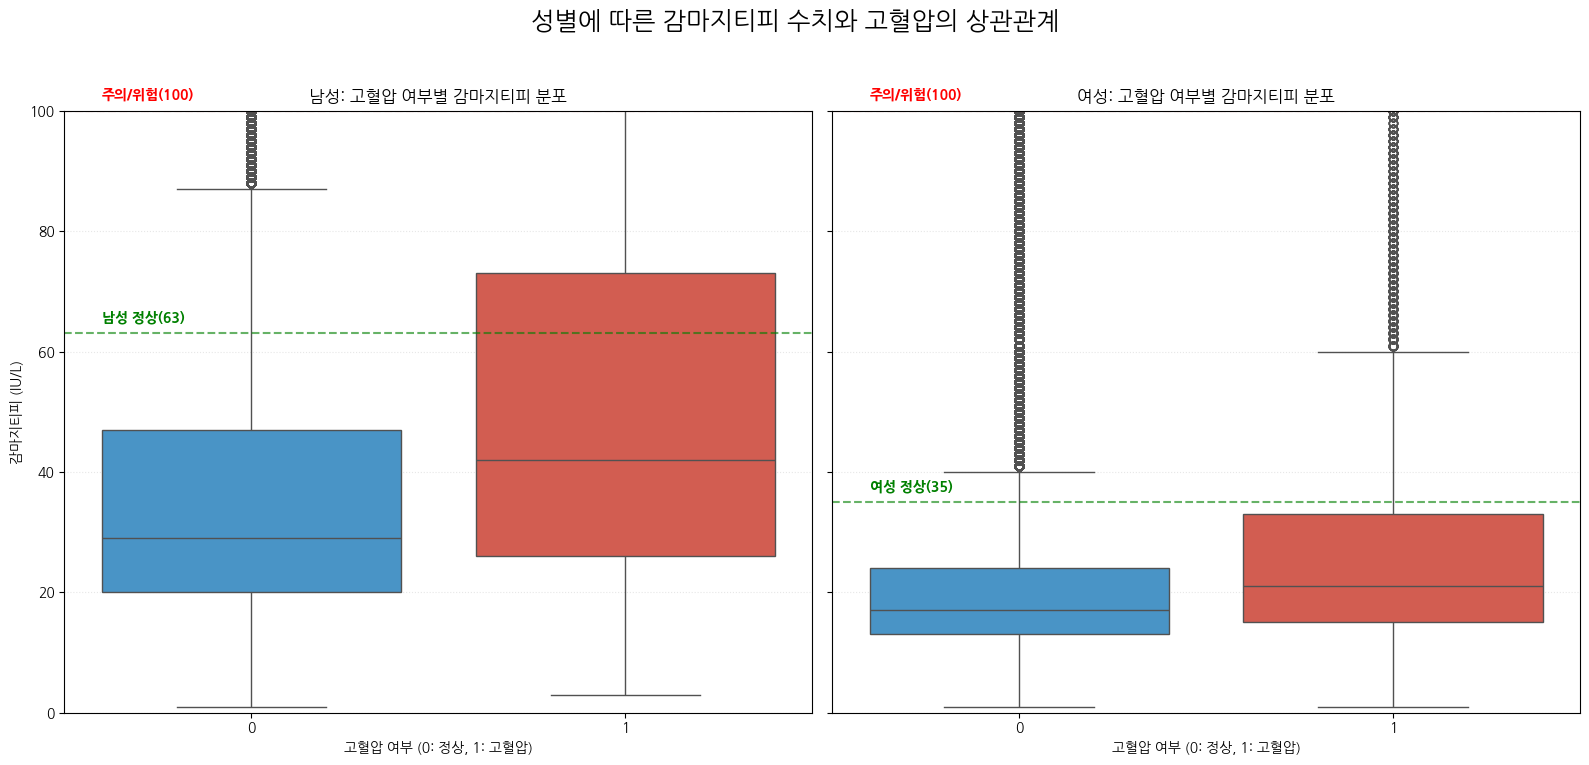

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 1. 데이터 타입 정리
cs_df['target'] = cs_df['target'].astype(str)
male_df = cs_df[cs_df['성별코드'] == 1].copy()
female_df = cs_df[cs_df['성별코드'] == 2].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# --- [좌: 남성 분석] ---
sns.boxplot(data=male_df, x='target', y='감마지티피', hue='target',
            palette={'0': '#3498db', '1': '#e74c3c'}, legend=False, ax=axes[0])
# 남성 기준선: 정상(63), 위험(100)
axes[0].axhline(y=63, color='green', linestyle='--', alpha=0.6)
axes[0].axhline(y=100, color='red', linestyle='--', alpha=0.6)
axes[0].text(-0.4, 65, '남성 정상(63)', color='green', fontweight='bold')
axes[0].text(-0.4, 102, '주의/위험(100)', color='red', fontweight='bold')
axes[0].set_title('남성: 고혈압 여부별 감마지티피 분포')

# --- [우: 여성 분석] ---
sns.boxplot(data=female_df, x='target', y='감마지티피', hue='target',
            palette={'0': '#3498db', '1': '#e74c3c'}, legend=False, ax=axes[1])
# 여성 기준선: 정상(35), 위험(100)
axes[1].axhline(y=35, color='green', linestyle='--', alpha=0.6)
axes[1].axhline(y=100, color='red', linestyle='--', alpha=0.6)
axes[1].text(-0.4, 37, '여성 정상(35)', color='green', fontweight='bold')
axes[1].text(-0.4, 102, '주의/위험(100)', color='red', fontweight='bold')
axes[1].set_title('여성: 고혈압 여부별 감마지티피 분포')

# 공통 설정
for ax in axes:
    ax.set_ylim(0, 100)
    ax.set_xlabel('고혈압 여부 (0: 정상, 1: 고혈압)')
    ax.set_ylabel('감마지티피 (IU/L)')
    ax.grid(axis='y', linestyle=':', alpha=0.3)

plt.suptitle('성별에 따른 감마지티피 수치와 고혈압의 상관관계', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

ㄹㅇ

모델 예측 정확도: 0.9485


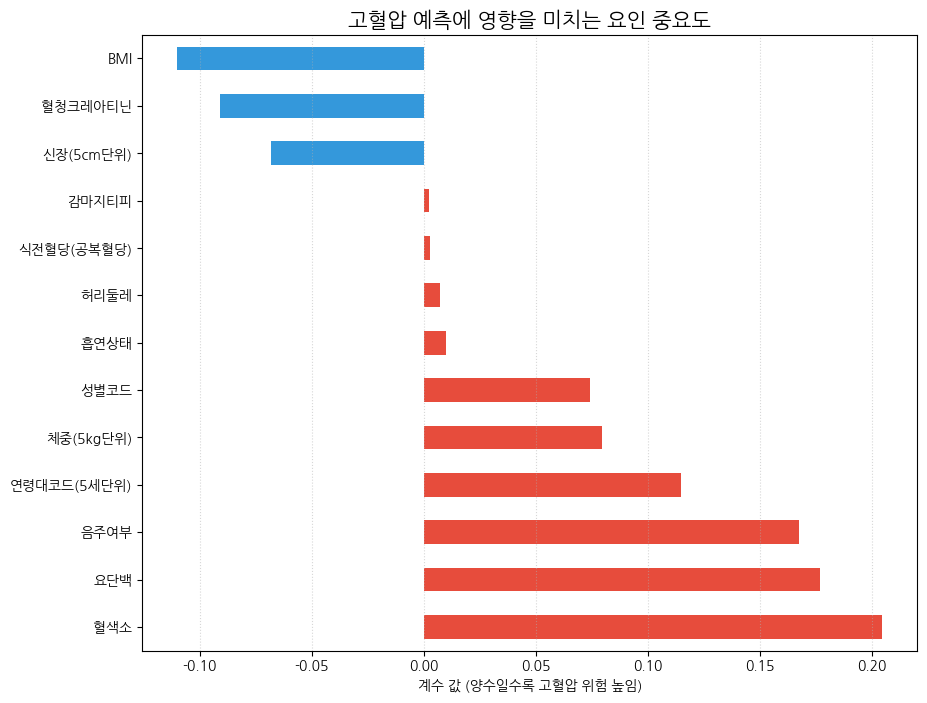

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# 1. 학습에 사용할 변수(X)와 정답(y) 분리
# 시각화용 임시 컬럼인 '분포', '분포_혈당'을 반드시 제거
drop_cols = ['target', '수축기혈압', '이완기혈압', '비만여부', '분포', '분포_혈당']
# 데이터프레임에 해당 컬럼이 있는지 확인 후 있는 것만 드롭 (안전한 방법)
X = cs_df.drop(columns=[c for c in drop_cols if c in cs_df.columns]).dropna()
y = cs_df.loc[X.index, 'target'].astype(int) # y는 숫자로 다시 변환

# 2. 데이터셋 분리 (학습용 80%, 테스트용 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. 로지스틱 회귀 모델 생성 및 학습
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4. 모델 성능 확인 (정확도)
y_pred = model.predict(X_test)
print(f"모델 예측 정확도: {accuracy_score(y_test, y_pred):.4f}")

# 5. 요인별 영향력(Coefficients) 확인
feature_influence = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
feature_influence.plot(kind='barh', color=['#e74c3c' if x > 0 else '#3498db' for x in feature_influence])
plt.title('고혈압 예측에 영향을 미치는 요인 중요도', fontsize=15)
plt.xlabel('계수 값 (양수일수록 고혈압 위험 높임)')
plt.grid(axis='x', linestyle=':', alpha=0.5)
plt.show()